In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[26.9715742]
-2.361485682842425


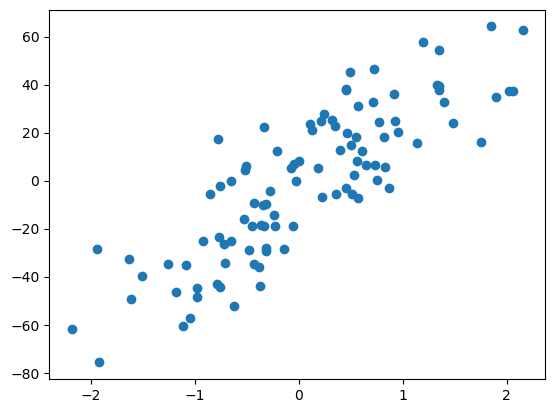

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

D:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
D:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
D:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.036e+04, tolerance: 7.400e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


[]

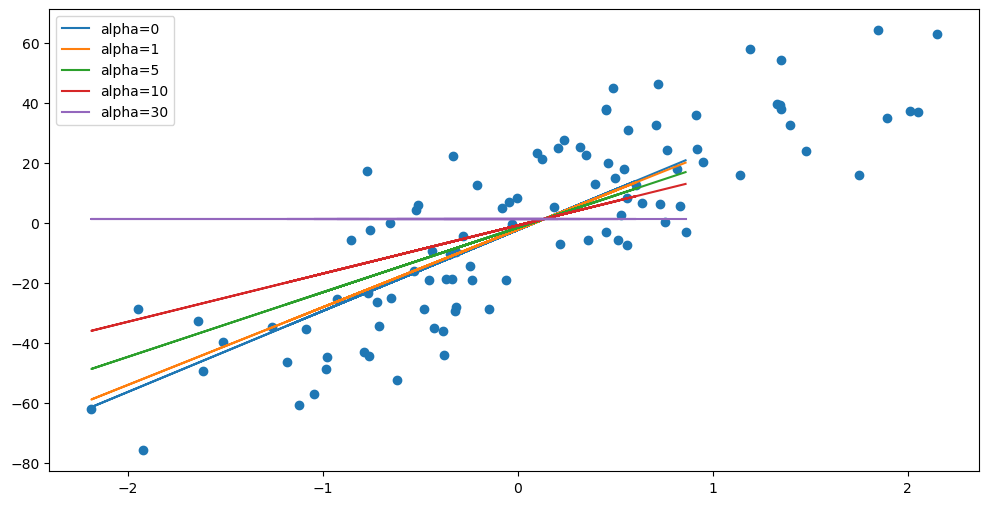

In [4]:
alphas=[0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L=Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.plot()

In [5]:
#slope decrease ho rha hai jaise alpha badha rhe hai ,yha zero hota hai coefficient ek time ke bad pr ridge regression me coefficient zero nhi hota tha

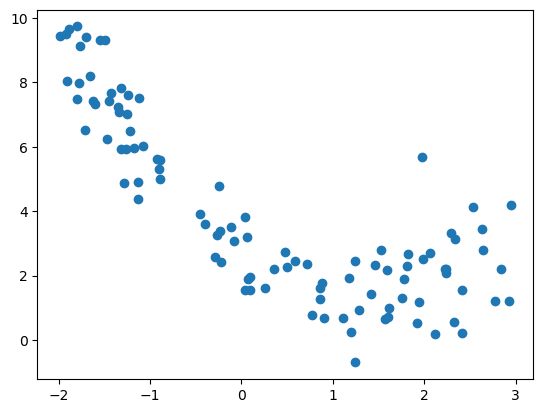

In [6]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

D:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
D:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
D:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.894e+01, tolerance: 7.734e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
D:\

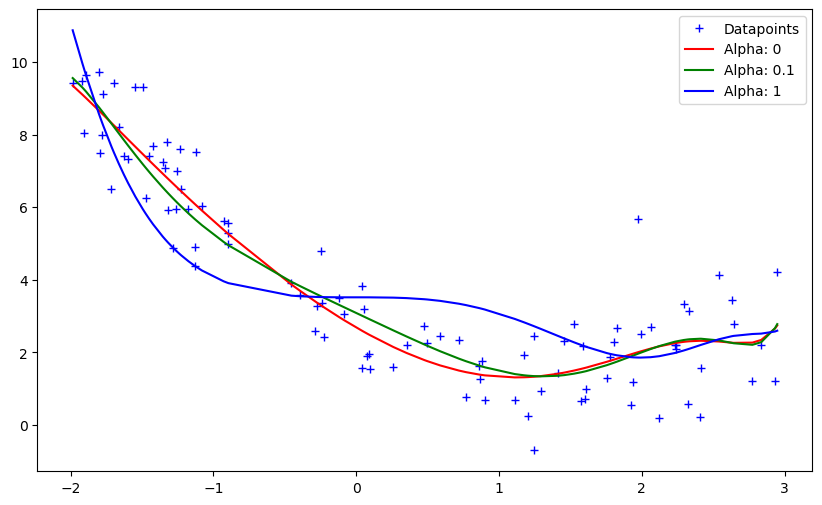

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

This code is showing how Lasso regression with polynomial features behaves under different regularization strengths (alpha values):

Pipeline setup:

PolynomialFeatures(degree=16) expands the input x1 into polynomial terms up to degree 16.

Lasso(alpha=alpha) fits a regression model with L1 regularization, which can shrink or zero out coefficients.

Function get_preds_lasso:

Builds the pipeline, fits it on the data (x1, x2), and returns predictions.

Loop over alphas:

Tests three values of alpha (0, 0.1, 1) to see how regularization changes the fitted curve.

alpha=0 means no regularization (just polynomial regression).

Larger alpha values enforce more sparsity, simplifying the curve and reducing overfitting.

Plotting:

Blue + marks show the original datapoints.

Each fitted curve is plotted in a different color (r, g, b) with a label showing its alpha.

Sorting ensures the curve is drawn smoothly along the x-axis.

👉 In short: the code compares how polynomial regression curves change when applying different levels of Lasso regularization, and visualizes the effect on the dataset.

Would you like me to also explain the difference between Lasso and Ridge (since you imported Ridge but used Lasso here)? That might help clarify why Lasso is chosen in this example.



In [8]:
#lasso regression feature selection me bhi kam aata hai,jb laso me hum alpha ki value badhate hai to jofeatures kam important hai unka value zero ho jata hia pr ridge regression me zero nhi hota kbhi ..near to zero hota hai ,so is wajh se hum jin coefficients ki value s zero nhi hui unhe lasso me rakh sakte hai bakiyo ko hata sakte hai